<a href="https://colab.research.google.com/github/rondinell/Intelig-ncia-Artificial/blob/main/ANALISEDERELATORIOCOMIASITE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

>>> Jarvis: Sintonizando redes neurais para Auditoria Fundamentalista...


Device set to use cpu



[INICIANDO AUDITORIA: SNID11] - 32 páginas detectadas.


Processando Páginas: 100%|██████████| 32/32 [00:54<00:00,  1.70s/it]


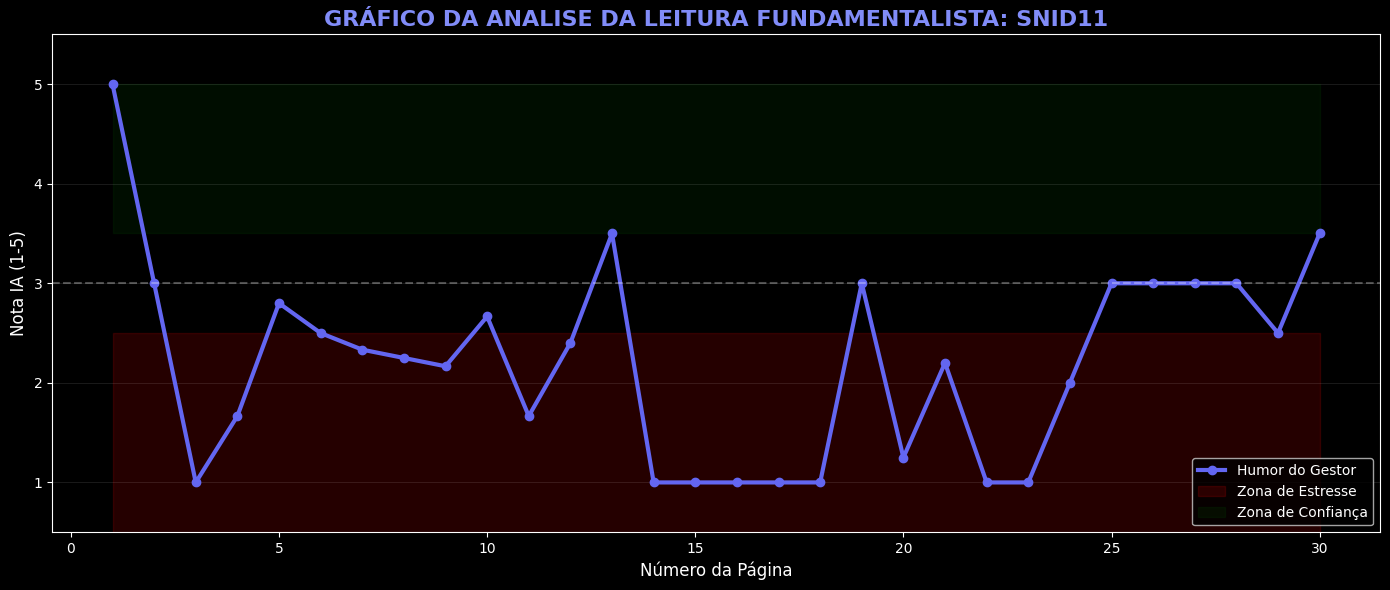


   RESUMO EXECUTIVO DE AUDITORIA - SNID11
SCORE GERAL: 2.20 / 5.0
STATUS: 🔴 RISCO ELEVADO - SENTIMENTO DEFENSIVO

--- PONTOS DE ATENÇÃO (TRECHOS CRÍTICOS) ---

[Pág 3]: "| 3 | I N D I C A D O R E S R$ 0,13 13,40% 16,24 % Distribuição por cota Dividend Yield (12 meses) * Dividend Yield Anualizado R$ 10,37 R$ 10,30 0,99 Cota Patrimonial * Cota Fechamento (Mercado )*..."

[Pág 3]: "uição de R$ 0,13 por cota , de acordo com o guidance de distribuição , que segue entre R$ 0,11 e R$ 0,13 por cota para o segundo semestre de 2025. A performance patrimonial do fundo no mês foi de..."

[Pág 3]: "de CDI + 4,60%. *Fechamento 31/10 **Gross -up: é a inserção da alíquota de imposto (IR) em produtos que oferecem isenção tributária, usado para demonstrar qual teria qu e ser o retorno necessário..."



In [3]:
# --- INSTALAÇÃO DAS FERRAMENTAS ---
!pip install -q transformers PyPDF2 tqdm pandas matplotlib

import os
import PyPDF2
import pandas as pd
import matplotlib.pyplot as plt
from transformers import pipeline
from tqdm import tqdm
import textwrap

# 1. SETUP DO CÉREBRO (IA BERT MULTILINGUAL)
print(">>> Jarvis: Sintonizando redes neurais para Auditoria Fundamentalista...")
sentimento_ia = pipeline("sentiment-analysis",
                         model="nlptown/bert-base-multilingual-uncased-sentiment")

def auditoria_jarvis_v2(caminho_pdf):
    # Identifica o nome do ativo pelo arquivo
    ticker = os.path.basename(caminho_pdf).replace(".pdf", "").split("-")[0].split("_")[0]

    # 2. LEITURA TÉCNICA
    reader = PyPDF2.PdfReader(caminho_pdf)
    total_paginas = len(reader.pages)
    dados_sentimento = []
    trechos_criticos = [] # Onde guardaremos os "problemas"

    print(f"\n[INICIANDO AUDITORIA: {ticker}] - {total_paginas} páginas detectadas.")

    # 3. MINERAÇÃO DE SENTIMENTO
    for num_pag in tqdm(range(total_paginas), desc="Processando Páginas"):
        texto_pag = reader.pages[num_pag].extract_text()
        if not texto_pag or len(texto_pag.strip()) < 20: continue

        # Divisão em blocos de 512 caracteres (limite do BERT)
        blocos = [texto_pag[i:i+512] for i in range(0, len(texto_pag), 512)]

        for trecho in blocos:
            try:
                res = sentimento_ia(trecho)[0]
                nota = int(res['label'][0])
                dados_sentimento.append({'Pagina': num_pag + 1, 'Nota': nota})

                # POKA-YOKE: Se a nota for 1 (Péssimo), salva o trecho para o resumo
                if nota == 1 and len(trecho) > 100:
                    trechos_criticos.append({'Pag': num_pag + 1, 'Texto': trecho.strip()})
            except: continue

    # 4. PROCESSAMENTO DE DADOS
    df = pd.DataFrame(dados_sentimento)
    media_por_pagina = df.groupby('Pagina')['Nota'].mean()

    # 5. VISUALIZAÇÃO DASHBOARD PROFISSIONAL
    plt.style.use('dark_background') # Estilo pro pro seu SaaS
    fig, ax = plt.subplots(figsize=(14, 6))

    # Linha principal
    ax.plot(media_por_pagina.index, media_por_pagina.values,
            marker='o', color='#6366f1', linewidth=3, label="Humor do Gestor")

    # Zonas de Risco (Sombreado)
    ax.fill_between(media_por_pagina.index, 0, 2.5, color='red', alpha=0.15, label="Zona de Estresse")
    ax.fill_between(media_por_pagina.index, 3.5, 5, color='green', alpha=0.1, label="Zona de Confiança")

    # Linha de Equilíbrio
    ax.axhline(y=3, color='white', linestyle='--', alpha=0.3)

    # Detalhes do Gráfico
    ax.set_title(f"GRÁFICO DA ANALISE DA LEITURA FUNDAMENTALISTA: {ticker}", fontsize=16, fontweight='bold', color='#818cf8')
    ax.set_xlabel("Número da Página", fontsize=12)
    ax.set_ylabel("Nota IA (1-5)", fontsize=12)
    ax.set_ylim(0.5, 5.5)
    ax.grid(axis='y', alpha=0.1)
    ax.legend()

    plt.tight_layout()
    plt.show()

    # 6. RESUMO EXECUTIVO (A cereja do bolo)
    score_geral = df['Nota'].mean()
    print(f"\n" + "="*60)
    print(f"   RESUMO EXECUTIVO DE AUDITORIA - {ticker}")
    print("="*60)
    print(f"SCORE GERAL: {score_geral:.2f} / 5.0")

    # Veredito dinâmico
    if score_geral < 2.8:
        print("STATUS: 🔴 RISCO ELEVADO - SENTIMENTO DEFENSIVO")
    elif score_geral < 3.5:
        print("STATUS: 🟡 NEUTRO - OPERAÇÃO SOB PRESSÃO")
    else:
        print("STATUS: 🟢 SAUDÁVEL - TOM OTIMISTA")

    print("\n--- PONTOS DE ATENÇÃO (TRECHOS CRÍTICOS) ---")
    if not trechos_criticos:
        print("Nenhum trecho de alerta máximo detectado.")
    else:
        # Pega os 3 trechos mais impactantes
        vistos = set()
        count = 0
        for item in trechos_criticos[:10]: # Analisa os primeiros 10 pra achar 3 únicos
            resumo = item['Texto'][:150].replace('\n', ' ')
            if resumo[:30] not in vistos and count < 3:
                print(f"\n[Pág {item['Pag']}]: \"{textwrap.shorten(item['Texto'], width=200, placeholder='...')}\"")
                vistos.add(resumo[:30])
                count += 1

    print("\n" + "="*60)

# --- EXECUÇÃO ---
# Basta colocar o nome do arquivo aqui
auditoria_jarvis_v2('SNID11_RG_OUT25.pdf')